<a href="https://colab.research.google.com/github/m4tt-nm/martino_DSPN_S26/blob/master/ExerciseSubmissions/17_regularized-regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 17: Regularized regression

This homework assignment is designed to give you an intuition as an interesting property of regularization in the context of ultra-high dimensional statistical problems.

You won't need to load in any data for this homework.

---
## 1. Simulating & visualizing data (2 points)

We are going to be looking at what happens in the context where $p>n$. In order to have total control over our data, we will use simulations for this homework. First, we will need to load the `glmnet`, `tidyverse`, and `ggplot2` libraries for this assignment.


In [1]:
# WRITE YOUR CODE HERE
install.packages("glmnet")
install.packages("tidyverse")
install.packages("ggplot2")
library(glmnet)
library(tidyverse)
library(ggplot2)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘iterators’, ‘foreach’, ‘shape’, ‘RcppEigen’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: Matrix

Loaded glmnet 4.1-10

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::expand() masks Matrix::expand()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ tidyr::pack()   masks Matrix::pack()
✖ tidyr::unpack() masks Matrix::unpack()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force a

We are going to generate a data set with complex structure and try to recover it using polynomial models. For simplicity sake, use the following code to produce a response variable, $y$ that has complex structure.

*Hint: Look up what a cosine function looks like if you need a reminder.*

In [7]:
# Generate data
set.seed(121)
sigma_noise <- .5
x <- seq(-9,9,by=.18)
n <- length(x)
y <- 0.1*x + cos(x) + cos(x/20)+rnorm(n,sd=sigma_noise)
dat <- data.frame(x=x, n=n, y=y, sigma_noise=sigma_noise)
#str(dat)

'data.frame':	101 obs. of  4 variables:
 $ x          : num  -9 -8.82 -8.64 -8.46 -8.28 -8.1 -7.92 -7.74 -7.56 -7.38 ...
 $ n          : int  101 101 101 101 101 101 101 101 101 101 ...
 $ y          : num  -1.038 -0.746 -0.6 -0.544 -0.683 ...
 $ sigma_noise: num  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 ...


(a) Break the data into a training set (n=50) and test set (n=51) using the `sample` function to randomly select subsets of x and y.  Make a separate data frame for the training and test data.

(**Note**: *Do not* just take the first 50 observations to be the training set and last 51 observations to be the test set.)

In [9]:
# WRITE YOUR CODE HERE
trainers <- sample(1:length(dat$x), 50)
train.dat <- dat[trainers,]
test.dat <- dat[-trainers,]

#trainers
#str(train.dat)
#str(test.dat)


[1]  27  65   3  84  91  10  88  56  70  71  81  98  93  34  15   8  19  53  46
[20]  55  20  44   2  26  77  47  58  67  38  74  79  64  13  80  63  87  61  94
[39]  31  97  72  43  90  22  66 101 100  41  57  39

(b) Plot the training data ($x$ \& $y$). Describe the relationship that you see in the training data.

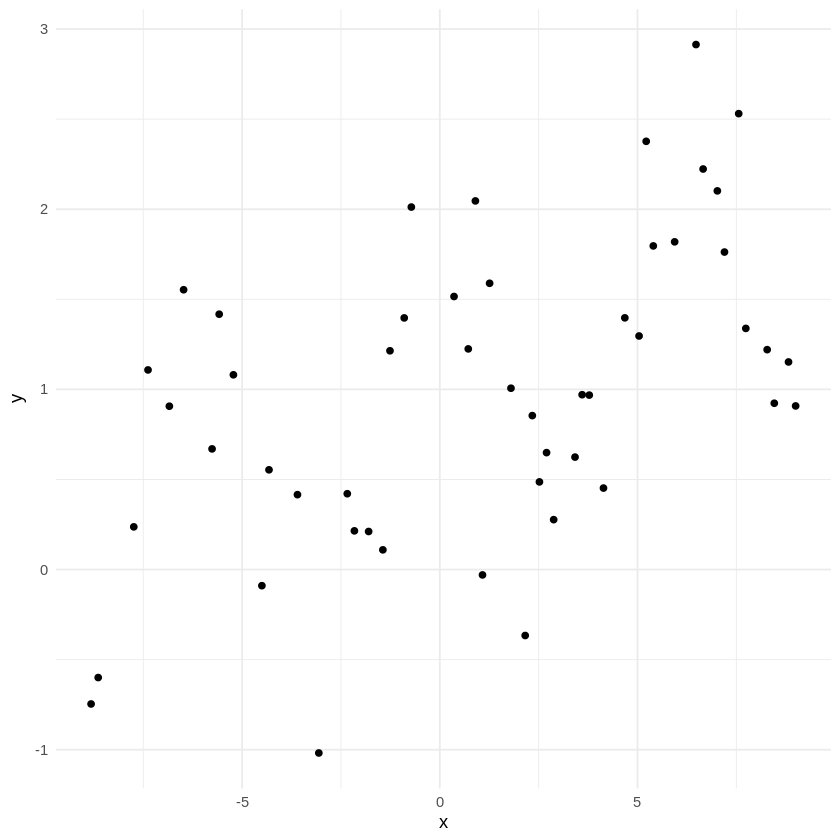

In [10]:
# WRITE YOUR CODE HERE
ggplot(train.dat, aes(x=x, y=y)) +
  geom_point() +
  theme_minimal()


How would you describe the relationship between $x$ and $y$ based on this plot?

> *I would say that x and y have a weak positively correlated relationship*
>

---
## 2. Bias-variance tradeoff: polynomial regression (4 points)

Recall that in polynomial regression we increase model complexity by expanding $x$ out to the power $k$ (which we call degree).

$$
Y = \hat{\beta}_0 + \sum_{j=1}^K \hat{\beta}_j X^j
\;=\; \operatorname{poly}(X, K)
$$

(a) Fit a 2nd degree polynomial regression model to the training data. Plot the results.


*Hint: Use the* `help` *function to see how to use the* `stat_smooth()` *and* `poly()` *functions.*

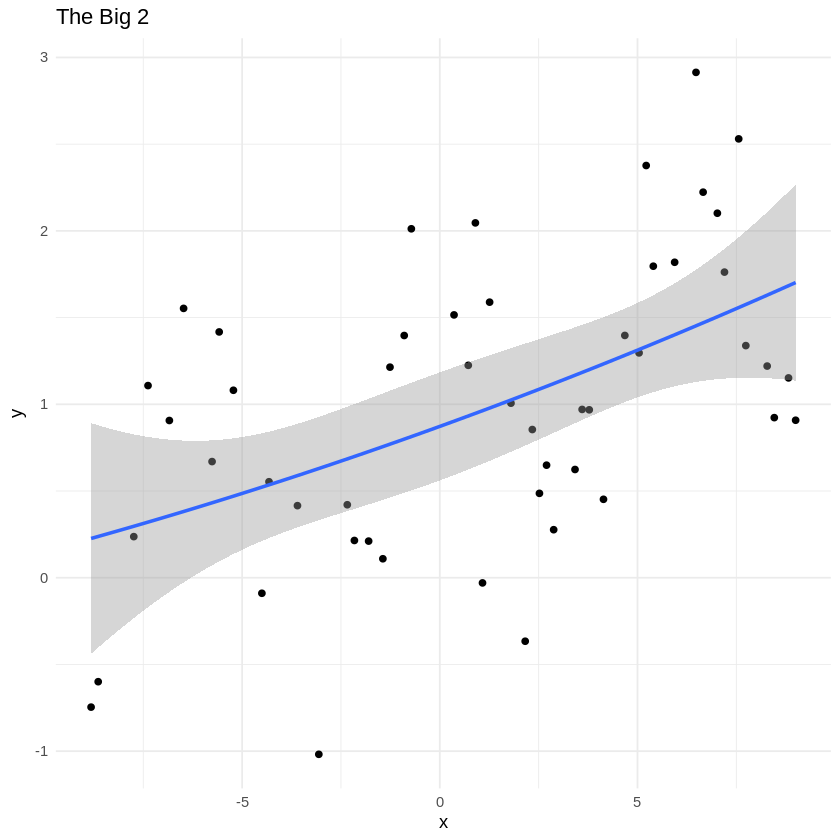

In [18]:
# WRITE YOUR CODE HERE
ggplot(train.dat, aes(x=x, y=y)) +
  geom_point() +
  stat_smooth(method = "lm",
              formula = y ~ poly(x, 2, raw = TRUE)) +
  labs(title = "The Big 2") +
  theme_minimal()


How well does this 2nd degree polynomial model qualitatively fit the data? Could it do better?

> *It follows the general positive trend but the actual function of the relationship (a cosine function) is not shown by the 2nd degree polynomial model, instead presenting a slightly convex linear model.*
>

(b) Fit a 12th degree polynomial to the data. Does this do qualitatively better or worse than the 2nd degree model?

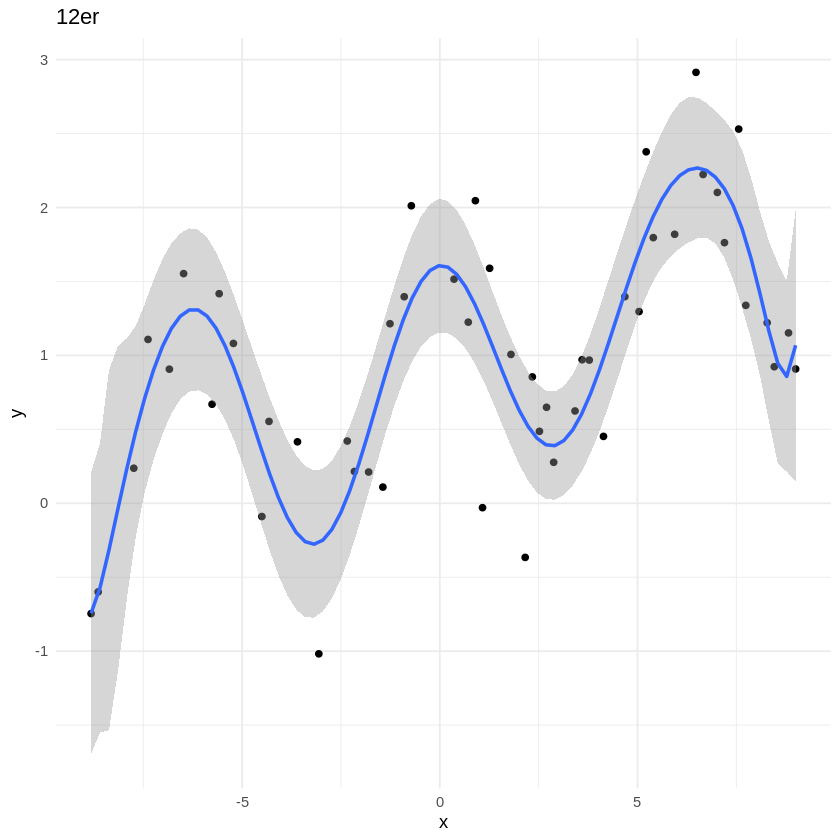

In [16]:
# WRITE YOUR CODE HERE
ggplot(train.dat, aes(x=x, y=y)) +
  geom_point() +
  stat_smooth(method = "lm",
              formula = y ~ poly(x, 12, raw = TRUE)) +
  labs(title = "12er") +
  theme_minimal()


> *This is much better as it fits more accurately the positive cosine function that is the coded relationship between these two variables*
>

(c) Modify the loop below to estimate the bias-variance tradeoff as model complexity (i.e., degree of the polynomial model, $k$) increases from 2 to 50. Use the training data to fit the model and test data to evaluate its predictive accuracy.

Visualize your results by plotting the *median* squared error for the training data and test data as a function of polynomial degree.


(**Note**: We are using median accuracies here because there are often 1 or 2 outlier values in the higher degree polynomial models that can throw off the accuracy estimates).

In [29]:
# Now do the variance-bias trade off analysis using regular regression
degree = seq(2,50)

# Need to setup your output vectors
train.rss = matrix(data=NA,nrow=length(degree),ncol=1)
test.rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {
    # WRITE YOUR CODE HERE
nth.model <- lm(y ~ poly(x, k, raw = TRUE), data = train.dat)

pred.fit <- predict(nth.model, newdata = train.dat)
pred.acc <- predict(nth.model, newdata = test.dat)

mse.fit <- median((train.dat$y - pred.fit)^2)
mse.acc <- median((test.dat$y - pred.acc)^2)

train.rss[(k-1), 1] <- mse.fit
test.rss[(k-1), 1] <- mse.acc
}

err.dat <- data.frame(degree=degree, train.rss=train.rss[,1], test.rss=test.rss[,1])

# Plot your results here
# WRITE YOUR CODE HERE
ggplot(err.dat, aes(x = degree)) +
  geom_point(aes(y = log10(train.rss), color = 'blue')) +
  geom_point(aes(y = log10(test.rss), color = 'red')) +
  geom_line(aes(y = log10(train.rss), color = 'blue')) +
  geom_line(aes(y = log10(test.rss), color = 'red')) +
  theme_minimal()


ERROR: Error in poly(x, k, raw = FALSE): 'degree' must be less than number of unique points


What do you see as $k$ increase?

> *The training error keeps decreasing, but after a certain point, the test error goes from decreasing to continuously increasing.*
>

(d) Now copy the code above and let's see what happens when we go beyond $p=n$ (remember, in this case $k=p$). Test polynomial models up to $k=150$. Visualize your results by plotting the *median* squared error for the training data and test data as a function of polynomial degree.

Use the `geom_vline()` function in `ggplot` to draw a vertical line where $k=n$ (here $n$ is the number of observations in the training set). This will make it clear where we cross the threshold for finding *unique* solutions in our data.



In [32]:
# WRITE YOUR CODE HERE
# Now do the variance-bias trade off analysis using regular regression
degree = seq(2,150)

# Need to setup your output vectors
train.rss = matrix(data=NA,nrow=length(degree),ncol=1)
test.rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {
    # WRITE YOUR CODE HERE
nth.model <- lm(y ~ poly(x, k, raw = FALSE), data = train.dat)

pred.fit <- predict(nth.model, newdata = train.dat)
pred.acc <- predict(nth.model, newdata = test.dat)

mse.fit <- median((train.dat$y - pred.fit)^2)
mse.acc <- median((test.dat$y - pred.acc)^2)

train.rss[(k-1), 1] <- mse.fit
test.rss[(k-1), 1] <- mse.acc
}

err.dat <- data.frame(degree=degree, train.rss=train.rss[,1], test.rss=test.rss[,1])

# Plot your results here
# WRITE YOUR CODE HERE
ggplot(err.dat, aes(x = degree)) +
  geom_point(aes(y = log10(train.rss), color = 'blue')) +
  geom_point(aes(y = log10(test.rss), color = 'red')) +
  geom_line(aes(y = log10(train.rss), color = 'blue')) +
  geom_line(aes(y = log10(test.rss), color = 'red')) +
  geom_vline(xintercept = 50) +
  theme_minimal()


ERROR: Error in poly(x, k, raw = FALSE): 'degree' must be less than number of unique points


In [31]:
sum(is.na(coef(nth.model)))

[1] 115

What do you see as $k$ gets larger than $n$?

> *Write your response here*
>

---
## 3. Applying regularization to the model fits (2 points)

Repeat the previous bias-variance tradeoff test, going up to $k=150$, but now use ridge regression with a sparsity parameter of $\lambda=0.00005$. Plot your results the same way as last time.

In [ ]:
# Now do the variance-bias trade off analysis using ridge regression
lambda=0.00005
degree = seq(2,150)

rm(train_rss, test_rss)
train_rss = matrix(data=NA,nrow=length(degree),ncol=1)
test_rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {
    # WRITE YOUR CODE HERE

}

# Plot your results here
# WRITE YOUR CODE HERE


What happens now when $k$ gets larger than $n$?

> *Write your response here*
>

---
## 4. Reflection (2 points)

The simulations above should have shown that, when applying a regularization (i.e., a sparsity constraint), the behavior of the bias-variance tradeoff changes. Explain why this happens.

> *Write your response here*
>

---
## Bonus (1 extra credit point)
Recall that the $p=n$ threshold defines the limit for finding a *unique* solution to $Y=F(X)$ (i.e., there is only one combination of regression coefficients that is *best* at explaining variance in $Y$). With this in mind, what is regularization doing that works around this upper limit?

> *Write your response here*
>

**DUE:** 11:59pm EST, April 7, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*